Imports and project paths

In [73]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

from rasterio.enums import Resampling
from rasterio.warp import reproject
from shapely.geometry import box

In [74]:
current_directory = Path.cwd()

if (current_directory / "data").exists():
    project_root = current_directory
else:
    project_root = current_directory.parent

red_2025_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2025-08-02"
    / "B04_2025-08-02.tif"
)

print("Project root:", project_root)
print("2025 raster exists:", red_2025_path.exists())

Project root: /Users/eleazar/Documents/wetland-change-manitoba
2025 raster exists: True


Create the study-area GeoJSON

In [75]:
reference_directory = project_root / "data" / "reference"
reference_directory.mkdir(parents=True, exist_ok=True)

aoi_output_path = reference_directory / "oak_hammock_study_area.geojson"

with rasterio.open(red_2025_path) as src:
    raster_bounds = src.bounds
    raster_crs = src.crs

study_area = gpd.GeoDataFrame(
    {
        "name": ["Oak Hammock Marsh study area"],
        "source": ["Sentinel-2 export extent"],
        "reference_date": ["2025-08-02"],
    },
    geometry=[box(*raster_bounds)],
    crs=raster_crs,
)

# Copernicus accepts geographic coordinates conveniently in WGS 84.
study_area_wgs84 = study_area.to_crs("EPSG:4326")

study_area_wgs84.to_file(
    aoi_output_path,
    driver="GeoJSON",
)

print("AOI saved to:")
print(aoi_output_path)

study_area_wgs84

AOI saved to:
/Users/eleazar/Documents/wetland-change-manitoba/data/reference/oak_hammock_study_area.geojson


,name,source,reference_date,geometry
0,Oak Hammock Marsh study area,Sentinel-2 export extent,2025-08-02,"POLYGON ((-96.88606 50.18233, -96.87793 50.365..."


Preview the study area

Text(36.472222222222214, 0.5, 'Latitude')

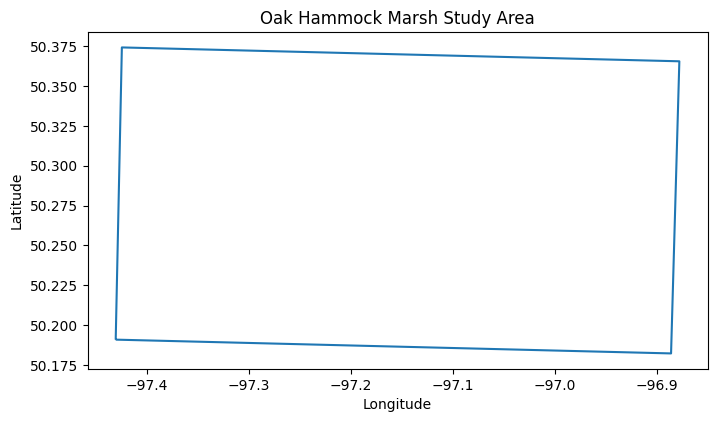

In [76]:
ax = study_area_wgs84.boundary.plot(figsize=(8, 6))

ax.set_title("Oak Hammock Marsh Study Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

Define all Sentinel-2 band paths

In [77]:
import numpy as np

red_2020_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2020-08-08"
    / "B04_2020-08-08.tif"
)

nir_2020_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2020-08-08"
    / "B08_2020-08-08.tif"
)

nir_2025_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2025-08-02"
    / "B08_2025-08-02.tif"
)

paths = {
    "2020 B04": red_2020_path,
    "2020 B08": nir_2020_path,
    "2025 B04": red_2025_path,
    "2025 B08": nir_2025_path,
}

for name, path in paths.items():
    print(f"{name}: {path.exists()} — {path}")

2020 B04: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2020-08-08/B04_2020-08-08.tif
2020 B08: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2020-08-08/B08_2020-08-08.tif
2025 B04: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2025-08-02/B04_2025-08-02.tif
2025 B08: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2025-08-02/B08_2025-08-02.tif


Raster metadata function

In [78]:
def get_raster_metadata(path):
    """Read the spatial and technical properties of a raster."""

    with rasterio.open(path) as src:
        return {
            "crs": src.crs,
            "width": src.width,
            "height": src.height,
            "shape": (src.height, src.width),
            "transform": src.transform,
            "bounds": src.bounds,
            "resolution": src.res,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
        }

Inspect the four rasters

In [79]:
metadata = {
    name: get_raster_metadata(path)
    for name, path in paths.items()
}

for name, info in metadata.items():
    print(f"\n{name}")
    print("-" * len(name))

    for key, value in info.items():
        print(f"{key}: {value}")


2020 B04
--------
crs: EPSG:32614
width: 2500
height: 1357
shape: (1357, 2500)
transform: | 15.79, 0.00, 612026.01|
| 0.00,-16.44, 5582386.34|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=612026.012689, bottom=5560081.552097, right=651500.116106, top=5582386.338637)
resolution: (15.789641366800014, 16.436836064848762)
dtype: uint16
nodata: None

2020 B08
--------
crs: EPSG:32614
width: 2500
height: 1357
shape: (1357, 2500)
transform: | 15.79, 0.00, 612026.01|
| 0.00,-16.44, 5582386.34|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=612026.012689, bottom=5560081.552097, right=651500.116106, top=5582386.338637)
resolution: (15.789641366800014, 16.436836064848762)
dtype: uint16
nodata: None

2025 B04
--------
crs: EPSG:32614
width: 2500
height: 1253
shape: (1253, 2500)
transform: | 15.57, 0.00, 612005.80|
| 0.00,-16.26, 5581419.63|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=612005.802059, bottom=5561042.057073, right=650919.85416, top=5581419.634547)
resolution: (15.565620840399992, 16.2

Function to compare raster grids

In [80]:
def compare_raster_grids(path_a, path_b):
    """Compare whether two rasters use the same spatial grid."""

    with rasterio.open(path_a) as raster_a, rasterio.open(path_b) as raster_b:
        return {
            "same_crs": raster_a.crs == raster_b.crs,
            "same_dimensions": (
                raster_a.width == raster_b.width
                and raster_a.height == raster_b.height
            ),
            "same_resolution": np.allclose(
                raster_a.res,
                raster_b.res,
            ),
            "same_transform": np.allclose(
                tuple(raster_a.transform),
                tuple(raster_b.transform),
            ),
            "same_bounds": np.allclose(
                tuple(raster_a.bounds),
                tuple(raster_b.bounds),
            ),
        }

Check alignment within each year

In [81]:
alignment_2020 = compare_raster_grids(
    red_2020_path,
    nir_2020_path,
)

alignment_2025 = compare_raster_grids(
    red_2025_path,
    nir_2025_path,
)

print("2020 B04 and B08 alignment")
for test, result in alignment_2020.items():
    print(f"{test}: {result}")

print("\n2025 B04 and B08 alignment")
for test, result in alignment_2025.items():
    print(f"{test}: {result}")

2020 B04 and B08 alignment
same_crs: True
same_dimensions: True
same_resolution: True
same_transform: True
same_bounds: True

2025 B04 and B08 alignment
same_crs: True
same_dimensions: True
same_resolution: True
same_transform: True
same_bounds: True


Compare the 2020 and 2025 grids

In [82]:
alignment_between_dates = compare_raster_grids(
    red_2020_path,
    red_2025_path,
)

print("2020 and 2025 grid comparison")

for test, result in alignment_between_dates.items():
    print(f"{test}: {result}")

2020 and 2025 grid comparison
same_crs: True
same_dimensions: False
same_resolution: False
same_transform: False
same_bounds: False


Import the alignment tools

In [83]:
from rasterio.enums import Resampling
from rasterio.warp import reproject

Create an alignment function

In [84]:
ALIGNMENT_NODATA = -9999.0


def align_to_reference(source_path, reference_path):
    """
    Resample a source raster onto the exact grid of a reference raster.

    The output inherits the reference raster's:
    - CRS
    - dimensions
    - transform
    - resolution
    - geographic extent
    """

    with rasterio.open(reference_path) as reference:
        destination = np.full(
            (reference.height, reference.width),
            ALIGNMENT_NODATA,
            dtype="float32",
        )

        reference_metadata = {
            "crs": reference.crs,
            "transform": reference.transform,
            "width": reference.width,
            "height": reference.height,
            "profile": reference.profile.copy(),
        }

    with rasterio.open(source_path) as source:
        source_array = source.read(
            1,
            masked=True,
        ).astype("float32")

        source_for_reprojection = source_array.filled(
            ALIGNMENT_NODATA
        )

        reproject(
            source=source_for_reprojection,
            destination=destination,
            src_transform=source.transform,
            src_crs=source.crs,
            src_nodata=ALIGNMENT_NODATA,
            dst_transform=reference_metadata["transform"],
            dst_crs=reference_metadata["crs"],
            dst_nodata=ALIGNMENT_NODATA,
            resampling=Resampling.bilinear,
        )

    aligned_array = np.ma.masked_equal(
        destination,
        ALIGNMENT_NODATA,
    )

    return aligned_array, reference_metadata

Align the 2020 bands to the 2025 grid

In [85]:
red_2020_aligned, reference_metadata = align_to_reference(
    red_2020_path,
    red_2025_path,
)

nir_2020_aligned, _ = align_to_reference(
    nir_2020_path,
    red_2025_path,
)

print("Aligned 2020 B04 shape:", red_2020_aligned.shape)
print("Aligned 2020 B08 shape:", nir_2020_aligned.shape)

print(
    "Aligned bands have the same shape:",
    red_2020_aligned.shape == nir_2020_aligned.shape,
)

Aligned 2020 B04 shape: (1253, 2500)
Aligned 2020 B08 shape: (1253, 2500)
Aligned bands have the same shape: True


Load the original 2025 bands

In [86]:
def read_masked_raster(path):
    """Read one raster band as a masked float32 array."""

    with rasterio.open(path) as source:
        return source.read(
            1,
            masked=True,
        ).astype("float32")


red_2025 = read_masked_raster(red_2025_path)
nir_2025 = read_masked_raster(nir_2025_path)

print("2025 B04 shape:", red_2025.shape)
print("2025 B08 shape:", nir_2025.shape)

print(
    "All four arrays now have the same shape:",
    red_2020_aligned.shape
    == nir_2020_aligned.shape
    == red_2025.shape
    == nir_2025.shape,
)

2025 B04 shape: (1253, 2500)
2025 B08 shape: (1253, 2500)
All four arrays now have the same shape: True


Calculate NDVI for both dates

In [87]:
def calculate_ndvi(red, nir):
    """Calculate NDVI while preserving invalid and NoData pixels."""

    red_values = red.filled(np.nan)
    nir_values = nir.filled(np.nan)

    denominator = nir_values + red_values

    with np.errstate(divide="ignore", invalid="ignore"):
        ndvi_values = (
            nir_values - red_values
        ) / denominator

    invalid_pixels = (
        np.ma.getmaskarray(red)
        | np.ma.getmaskarray(nir)
        | ~np.isfinite(ndvi_values)
        | (denominator == 0)
    )

    ndvi = np.ma.array(
        np.clip(ndvi_values, -1, 1),
        mask=invalid_pixels,
    )

    return ndvi


ndvi_2020 = calculate_ndvi(
    red_2020_aligned,
    nir_2020_aligned,
)

ndvi_2025 = calculate_ndvi(
    red_2025,
    nir_2025,
)

print("2020 NDVI shape:", ndvi_2020.shape)
print("2025 NDVI shape:", ndvi_2025.shape)

print()
print("2020 NDVI mean:", float(ndvi_2020.mean()))
print("2025 NDVI mean:", float(ndvi_2025.mean()))

2020 NDVI shape: (1253, 2500)
2025 NDVI shape: (1253, 2500)

2020 NDVI mean: 0.5867086659085022
2025 NDVI mean: 0.6009170746909736


Restrict both dates to their common valid area

In [88]:
valid_overlap = (
    ~np.ma.getmaskarray(ndvi_2020)
    & ~np.ma.getmaskarray(ndvi_2025)
)

ndvi_2020_common = np.ma.array(
    ndvi_2020,
    mask=~valid_overlap,
)

ndvi_2025_common = np.ma.array(
    ndvi_2025,
    mask=~valid_overlap,
)

valid_pixel_count = int(valid_overlap.sum())
total_pixel_count = valid_overlap.size

valid_percentage = (
    valid_pixel_count / total_pixel_count
) * 100

print("Valid overlapping pixels:", valid_pixel_count)
print(f"Valid overlap: {valid_percentage:.2f}%")

Valid overlapping pixels: 2563600
Valid overlap: 81.84%


This prevents areas missing from either acquisition from being interpreted as vegetation change.

## Compare mean NDVI over the common valid area

To ensure a fair comparison, mean NDVI is calculated only for pixels that contain valid observations in both 2020 and 2025. This prevents differences in raster coverage or missing pixels from influencing the comparison.

In [89]:
mean_ndvi_2020_common = float(
    ndvi_2020_common.mean()
)

mean_ndvi_2025_common = float(
    ndvi_2025_common.mean()
)

difference_between_means = (
    mean_ndvi_2025_common
    - mean_ndvi_2020_common
)

print(
    f"2020 mean NDVI over common area: "
    f"{mean_ndvi_2020_common:.4f}"
)

print(
    f"2025 mean NDVI over common area: "
    f"{mean_ndvi_2025_common:.4f}"
)

print(
    f"Difference between common-area means: "
    f"{difference_between_means:+.4f}"
)

2020 mean NDVI over common area: 0.5956
2025 mean NDVI over common area: 0.6009
Difference between common-area means: +0.0053


## Calculate NDVI change

The direction will be:

NDVI change = 2025 NDVI − 2020 NDVI

In [90]:
ndvi_change = ndvi_2025_common - ndvi_2020_common

print("Minimum NDVI change:", float(ndvi_change.min()))
print("Maximum NDVI change:", float(ndvi_change.max()))
print("Mean NDVI change:", float(ndvi_change.mean()))
print("Median NDVI change:", float(np.ma.median(ndvi_change)))

mean_pixel_change = float(
    ndvi_change.mean()
)

print(
    "Difference of means matches mean change:",
    np.isclose(
        difference_between_means,
        mean_pixel_change,
        atol=1e-6,
    ),
)

Minimum NDVI change: -1.855431318283081
Maximum NDVI change: 0.8903528451919556
Mean NDVI change: 0.0053318724005061244
Median NDVI change: 0.012064486742019653
Difference of means matches mean change: True


## Plot the change map

In [91]:
from matplotlib.ticker import FuncFormatter
from rasterio.transform import array_bounds

# Calculate the geographic bounds of the 2025 reference grid.
raster_height = reference_metadata["height"]
raster_width = reference_metadata["width"]
raster_transform = reference_metadata["transform"]

west, south, east, north = array_bounds(
    raster_height,
    raster_width,
    raster_transform,
)

map_extent = (
    west,
    east,
    south,
    north,
)

print("West:", west)
print("East:", east)
print("South:", south)
print("North:", north)

West: 612005.802059
East: 650919.85416
South: 5561042.057073
North: 5581419.634547


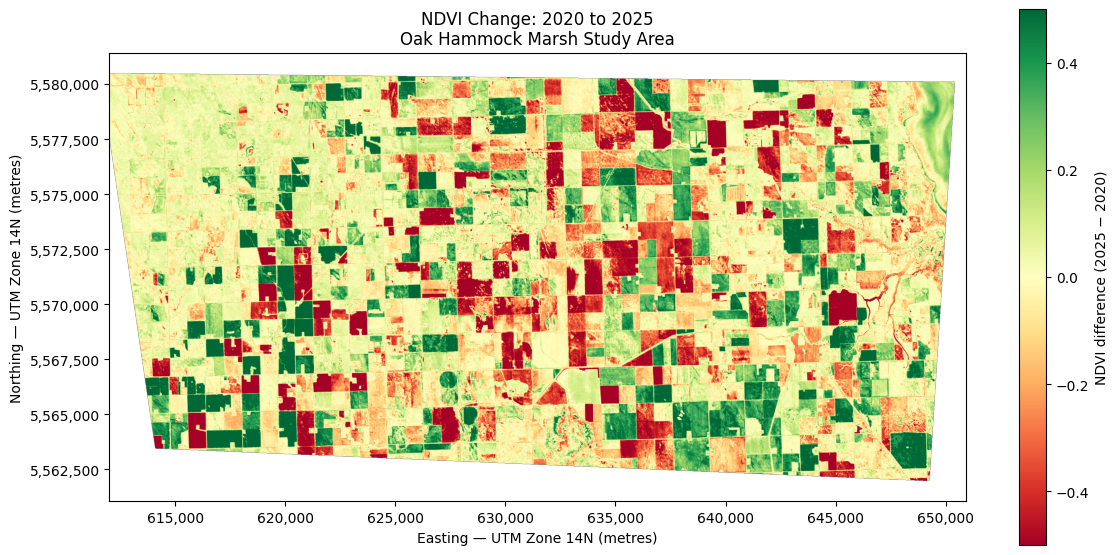

Figure saved to:
/Users/eleazar/Documents/wetland-change-manitoba/outputs/figures/ndvi_change_2020_2025.png


In [92]:
fig, ax = plt.subplots(figsize=(12, 7))

change_image = ax.imshow(
    ndvi_change,
    cmap="RdYlGn",
    vmin=-0.5,
    vmax=0.5,
    extent=map_extent,
    origin="upper",
)

ax.set_title(
    "NDVI Change: 2020 to 2025\n"
    "Oak Hammock Marsh Study Area"
)

ax.set_xlabel(
    "Easting — UTM Zone 14N (metres)"
)

ax.set_ylabel(
    "Northing — UTM Zone 14N (metres)"
)

# Display coordinates with commas and no scientific notation.
coordinate_formatter = FuncFormatter(
    lambda value, position: f"{value:,.0f}"
)

ax.xaxis.set_major_formatter(
    coordinate_formatter
)

ax.yaxis.set_major_formatter(
    coordinate_formatter
)

ax.set_aspect("equal")

colorbar = fig.colorbar(
    change_image,
    ax=ax,
    shrink=0.8,
)

colorbar.set_label(
    "NDVI difference (2025 − 2020)"
)

plt.tight_layout()

figures_directory = (
    project_root
    / "outputs"
    / "figures"
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)

change_figure_path = (
    figures_directory
    / "ndvi_change_2020_2025.png"
)

fig.savefig(
    change_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:")
print(change_figure_path)

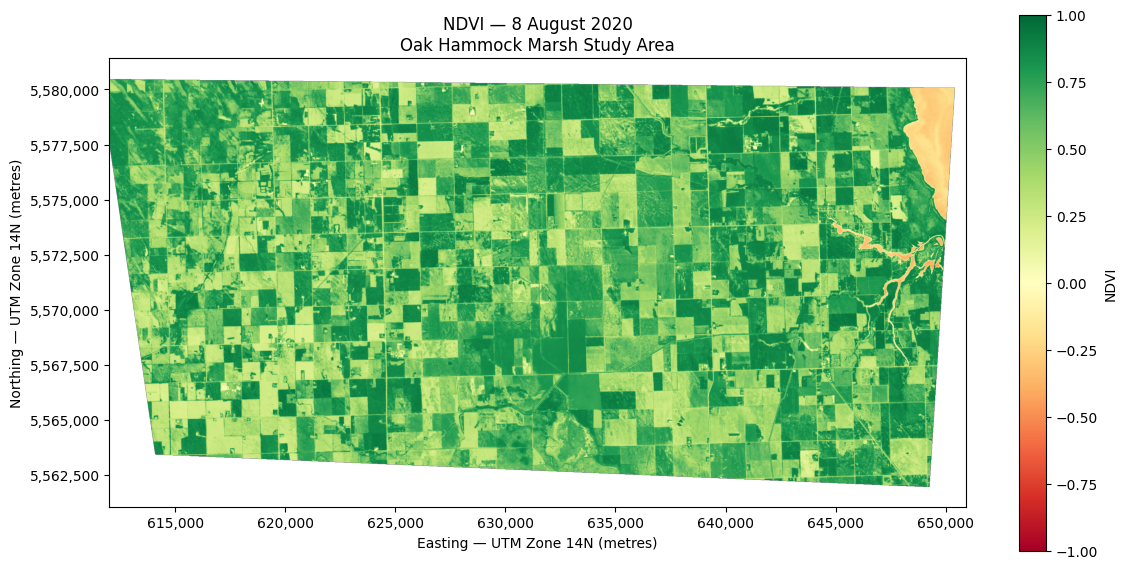

Figure saved to:
/Users/eleazar/Documents/wetland-change-manitoba/outputs/figures/ndvi_2020.png


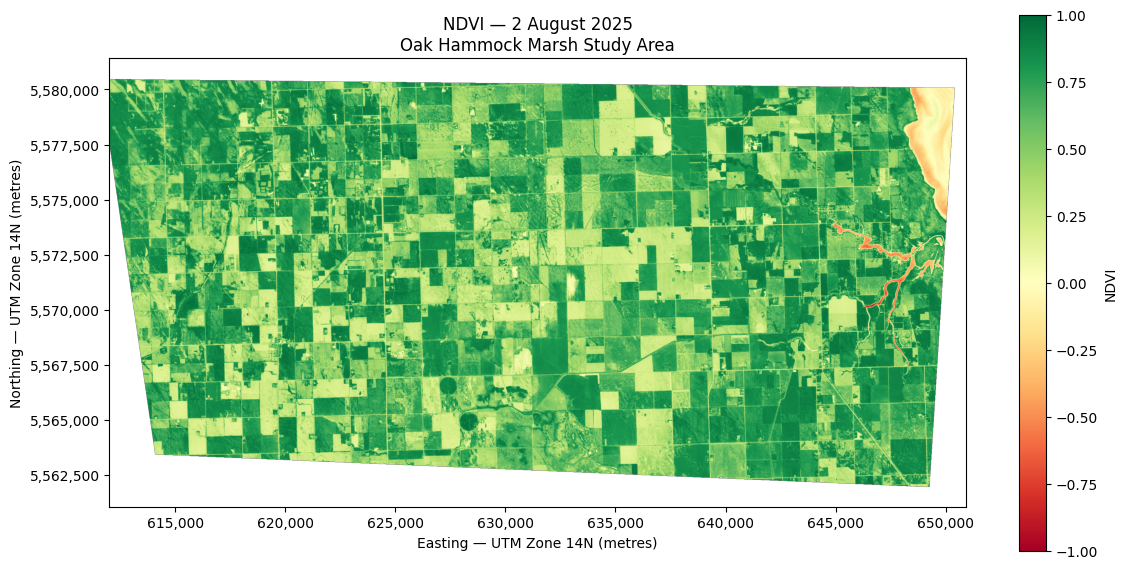

Figure saved to:
/Users/eleazar/Documents/wetland-change-manitoba/outputs/figures/ndvi_2025.png


In [93]:
def save_ndvi_figure(
    ndvi,
    title,
    output_path,
    extent,
):
    """
    Create and save a georeferenced NDVI visualization.

    Parameters
    ----------
    ndvi : numpy.ma.MaskedArray
        NDVI raster values.

    title : str
        Figure title.

    output_path : pathlib.Path
        Location where the PNG will be saved.

    extent : tuple
        Raster bounds in the order:
        west, east, south, north.
    """

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    image = ax.imshow(
        ndvi,
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        extent=extent,
        origin="upper",
    )

    ax.set_title(title)

    ax.set_xlabel(
        "Easting — UTM Zone 14N (metres)"
    )

    ax.set_ylabel(
        "Northing — UTM Zone 14N (metres)"
    )

    coordinate_formatter = FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )

    ax.xaxis.set_major_formatter(
        coordinate_formatter
    )

    ax.yaxis.set_major_formatter(
        coordinate_formatter
    )

    ax.set_aspect("equal")

    colorbar = fig.colorbar(
        image,
        ax=ax,
        shrink=0.8,
    )

    colorbar.set_label("NDVI")

    plt.tight_layout()

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Figure saved to:")
    print(output_path)


save_ndvi_figure(
    ndvi_2020_common,
    (
        "NDVI — 8 August 2020\n"
        "Oak Hammock Marsh Study Area"
    ),
    figures_directory / "ndvi_2020.png",
    map_extent,
)

save_ndvi_figure(
    ndvi_2025_common,
    (
        "NDVI — 2 August 2025\n"
        "Oak Hammock Marsh Study Area"
    ),
    figures_directory / "ndvi_2025.png",
    map_extent,
)

## Save analytical raster outputs

The 2020 NDVI raster has been aligned to the 2025 reference grid. The aligned 2020 NDVI and the 2020–2025 NDVI difference are exported as georeferenced GeoTIFF files for later GIS analysis, classification, area calculations, and dashboard development.

In [94]:
OUTPUT_NODATA = -9999.0

processed_directory = project_root / "data" / "processed"
processed_directory.mkdir(parents=True, exist_ok=True)

ndvi_2020_output_path = (
    processed_directory
    / "ndvi_2020-08-08_aligned.tif"
)

ndvi_change_output_path = (
    processed_directory
    / "ndvi_change_2020-2025.tif"
)

# Copy the 2025 reference-grid profile.
# This ensures the new rasters use the same CRS, dimensions,
# pixel size, transform, and geographic extent as the 2025 image.
output_profile = reference_metadata["profile"].copy()

output_profile.update(
    driver="GTiff",
    dtype="float32",
    count=1,
    height=reference_metadata["height"],
    width=reference_metadata["width"],
    crs=reference_metadata["crs"],
    transform=reference_metadata["transform"],
    nodata=OUTPUT_NODATA,
    compress="lzw",
)


def save_masked_geotiff(array, output_path, profile):
    """
    Save a masked NumPy array as a single-band georeferenced GeoTIFF.

    Masked or invalid pixels are written using the selected NoData value.
    """

    clean_array = np.ma.masked_invalid(
        np.ma.asarray(array)
    )

    values_to_save = clean_array.filled(
        OUTPUT_NODATA
    ).astype("float32")

    with rasterio.open(
        output_path,
        "w",
        **profile,
    ) as destination:
        destination.write(values_to_save, 1)
        destination.set_band_description(
            1,
            output_path.stem,
        )


save_masked_geotiff(
    ndvi_2020,
    ndvi_2020_output_path,
    output_profile,
)

save_masked_geotiff(
    ndvi_change,
    ndvi_change_output_path,
    output_profile,
)

print("Analytical rasters saved:")
print(ndvi_2020_output_path)
print(ndvi_change_output_path)

Analytical rasters saved:
/Users/eleazar/Documents/wetland-change-manitoba/data/processed/ndvi_2020-08-08_aligned.tif
/Users/eleazar/Documents/wetland-change-manitoba/data/processed/ndvi_change_2020-2025.tif


## Validate the saved analytical rasters

The exported GeoTIFF files are reopened to confirm their coordinate reference system, dimensions, resolution, data type, NoData value, numerical range, and alignment with the 2025 reference grid.

In [95]:
analytical_outputs = [
    ndvi_2020_output_path,
    ndvi_change_output_path,
]

for output_path in analytical_outputs:
    with rasterio.open(output_path) as source:
        raster = source.read(
            1,
            masked=True,
        )

        print(f"\n{output_path.name}")
        print("-" * len(output_path.name))
        print("CRS:", source.crs)
        print("Dimensions:", source.width, "x", source.height)
        print("Resolution:", source.res)
        print("Data type:", source.dtypes[0])
        print("NoData:", source.nodata)
        print("Minimum:", float(raster.min()))
        print("Maximum:", float(raster.max()))
        print(
            "Matches 2025 reference transform:",
            source.transform
            == reference_metadata["transform"],
        )


ndvi_2020-08-08_aligned.tif
---------------------------
CRS: EPSG:32614
Dimensions: 2500 x 1253
Resolution: (15.565620840399992, 16.26303070550673)
Data type: float32
NoData: -9999.0
Minimum: -0.48923373222351074
Maximum: 0.9481825232505798
Matches 2025 reference transform: True

ndvi_change_2020-2025.tif
-------------------------
CRS: EPSG:32614
Dimensions: 2500 x 1253
Resolution: (15.565620840399992, 16.26303070550673)
Data type: float32
NoData: -9999.0
Minimum: -1.855431318283081
Maximum: 0.8903528451919556
Matches 2025 reference transform: True


## Classify NDVI change

The continuous NDVI-difference raster is grouped into three exploratory classes:

- **Decrease:** NDVI change below -0.10
- **Stable:** NDVI change from -0.10 to +0.10
- **Increase:** NDVI change above +0.10

The ±0.10 threshold is used to reduce the influence of small differences caused by image timing, atmospheric conditions, resampling, and other sources of variability.

These classes describe spectral vegetation change and should not yet be interpreted as confirmed wetland degradation or improvement.

In [96]:
NDVI_CHANGE_THRESHOLD = 0.10

change_values = ndvi_change.filled(np.nan)

# Class codes:
# 0 = NoData
# 1 = NDVI decrease
# 2 = Relatively stable
# 3 = NDVI increase
change_classes = np.zeros(
    ndvi_change.shape,
    dtype="uint8",
)

valid_change_pixels = (
    ~np.ma.getmaskarray(ndvi_change)
    & np.isfinite(change_values)
)

change_classes[
    valid_change_pixels
    & (change_values < -NDVI_CHANGE_THRESHOLD)
] = 1

change_classes[
    valid_change_pixels
    & (change_values >= -NDVI_CHANGE_THRESHOLD)
    & (change_values <= NDVI_CHANGE_THRESHOLD)
] = 2

change_classes[
    valid_change_pixels
    & (change_values > NDVI_CHANGE_THRESHOLD)
] = 3

change_classes_masked = np.ma.masked_where(
    change_classes == 0,
    change_classes,
)

print(
    "Decrease pixels:",
    int(np.count_nonzero(change_classes == 1)),
)

print(
    "Stable pixels:",
    int(np.count_nonzero(change_classes == 2)),
)

print(
    "Increase pixels:",
    int(np.count_nonzero(change_classes == 3)),
)

print(
    "Total classified pixels:",
    int(np.count_nonzero(change_classes)),
)

print(
    "Matches valid change-pixel count:",
    np.count_nonzero(change_classes)
    == np.count_nonzero(valid_change_pixels),
)

Decrease pixels: 687003
Stable pixels: 1174393
Increase pixels: 702204
Total classified pixels: 2563600
Matches valid change-pixel count: True


## Calculate area statistics

The area represented by one raster pixel is calculated from the affine transformation of the 2025 reference grid. Pixel counts are then converted to hectares and percentages of the common valid study area.

In [97]:
import pandas as pd

reference_transform = reference_metadata["transform"]

# Determinant of the affine transformation.
# This remains valid even if rotation terms are present.
pixel_area_square_metres = abs(
    reference_transform.a * reference_transform.e
    - reference_transform.b * reference_transform.d
)

pixel_area_hectares = (
    pixel_area_square_metres / 10_000
)

classified_pixel_count = int(
    np.count_nonzero(change_classes)
)

classified_area_hectares = (
    classified_pixel_count
    * pixel_area_hectares
)

print(
    f"Pixel area: "
    f"{pixel_area_square_metres:.2f} square metres"
)

print(
    f"Pixel area: "
    f"{pixel_area_hectares:.4f} hectares"
)

print(
    f"Common valid area: "
    f"{classified_area_hectares:,.2f} hectares"
)

Pixel area: 253.14 square metres
Pixel area: 0.0253 hectares
Common valid area: 64,896.04 hectares


## Create the statistics table

In [98]:
class_definitions = {
    1: {
        "class": "NDVI decrease",
        "definition": "Change < -0.10",
    },
    2: {
        "class": "Relatively stable",
        "definition": "-0.10 ≤ change ≤ +0.10",
    },
    3: {
        "class": "NDVI increase",
        "definition": "Change > +0.10",
    },
}

statistics_records = []

for class_code, class_information in class_definitions.items():
    pixel_count = int(
        np.count_nonzero(
            change_classes == class_code
        )
    )

    area_hectares = (
        pixel_count
        * pixel_area_hectares
    )

    percentage = (
        pixel_count
        / classified_pixel_count
        * 100
    )

    statistics_records.append(
        {
            "Class code": class_code,
            "Change class": class_information["class"],
            "Definition": class_information["definition"],
            "Pixel count": pixel_count,
            "Area (ha)": area_hectares,
            "Percentage (%)": percentage,
        }
    )

change_statistics = pd.DataFrame(
    statistics_records
)

change_statistics["Area (ha)"] = (
    change_statistics["Area (ha)"]
    .round(2)
)

change_statistics["Percentage (%)"] = (
    change_statistics["Percentage (%)"]
    .round(2)
)

change_statistics

,Class code,Change class,Definition,Pixel count,Area (ha),Percentage (%)
0,1,NDVI decrease,Change < -0.10,687003,17391.08,26.80
1,2,Relatively stable,-0.10 ≤ change ≤ +0.10,1174393,29729.07,45.81
2,3,NDVI increase,Change > +0.10,702204,17775.88,27.39


## Validate the statistics

In [99]:
statistics_pixel_total = int(
    change_statistics["Pixel count"].sum()
)

statistics_area_total = float(
    change_statistics["Area (ha)"].sum()
)

statistics_percentage_total = float(
    change_statistics["Percentage (%)"].sum()
)

print(
    "Pixel totals match:",
    statistics_pixel_total
    == classified_pixel_count,
)

print(
    f"Area represented by classes: "
    f"{statistics_area_total:,.2f} hectares"
)

print(
    f"Percentage total: "
    f"{statistics_percentage_total:.2f}%"
)

Pixel totals match: True
Area represented by classes: 64,896.03 hectares
Percentage total: 100.00%


## Save the statistics as CSV

In [100]:
tables_directory = (
    project_root
    / "outputs"
    / "tables"
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)

statistics_output_path = (
    tables_directory
    / "ndvi_change_class_statistics.csv"
)

change_statistics.to_csv(
    statistics_output_path,
    index=False,
)

print("Statistics saved to:")
print(statistics_output_path)

Statistics saved to:
/Users/eleazar/Documents/wetland-change-manitoba/outputs/tables/ndvi_change_class_statistics.csv


## Map the NDVI-change classes

The classified map provides a simplified view of locations showing NDVI decrease, relative stability, and NDVI increase between August 2020 and August 2025.

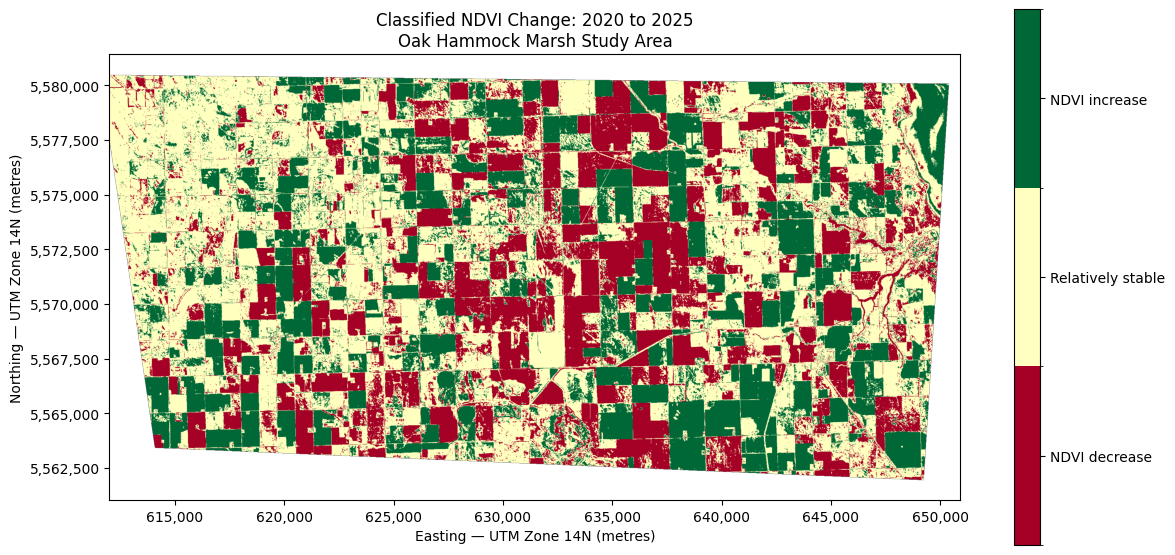

Classified figure saved to:
/Users/eleazar/Documents/wetland-change-manitoba/outputs/figures/ndvi_change_classes_2020_2025.png


In [101]:
from matplotlib.colors import BoundaryNorm

class_cmap = plt.get_cmap(
    "RdYlGn",
    3,
)

class_norm = BoundaryNorm(
    boundaries=[0.5, 1.5, 2.5, 3.5],
    ncolors=class_cmap.N,
)

fig, ax = plt.subplots(
    figsize=(12, 7)
)

classified_image = ax.imshow(
    change_classes_masked,
    cmap=class_cmap,
    norm=class_norm,
    extent=map_extent,
    origin="upper",
)

ax.set_title(
    "Classified NDVI Change: 2020 to 2025\n"
    "Oak Hammock Marsh Study Area"
)

ax.set_xlabel(
    "Easting — UTM Zone 14N (metres)"
)

ax.set_ylabel(
    "Northing — UTM Zone 14N (metres)"
)

ax.xaxis.set_major_formatter(
    coordinate_formatter
)

ax.yaxis.set_major_formatter(
    coordinate_formatter
)

ax.set_aspect("equal")

colorbar = fig.colorbar(
    classified_image,
    ax=ax,
    ticks=[1, 2, 3],
    shrink=0.8,
)

colorbar.ax.set_yticklabels(
    [
        "NDVI decrease",
        "Relatively stable",
        "NDVI increase",
    ]
)

plt.tight_layout()

classified_figure_path = (
    figures_directory
    / "ndvi_change_classes_2020_2025.png"
)

fig.savefig(
    classified_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Classified figure saved to:")
print(classified_figure_path)

In [102]:
classified_raster_path = (
    processed_directory
    / "ndvi_change_classes_2020-2025.tif"
)

classification_profile = (
    reference_metadata["profile"].copy()
)

classification_profile.update(
    driver="GTiff",
    dtype="uint8",
    count=1,
    nodata=0,
    compress="lzw",
)

with rasterio.open(
    classified_raster_path,
    "w",
    **classification_profile,
) as destination:
    destination.write(
        change_classes,
        1,
    )

    destination.set_band_description(
        1,
        "NDVI change class",
    )

    destination.update_tags(
        1,
        class_0="NoData",
        class_1="NDVI decrease: change below -0.10",
        class_2="Relatively stable: -0.10 to +0.10",
        class_3="NDVI increase: change above +0.10",
    )

print("Classified raster saved to:")
print(classified_raster_path)

Classified raster saved to:
/Users/eleazar/Documents/wetland-change-manitoba/data/processed/ndvi_change_classes_2020-2025.tif
